    LOD  Map Size (pixels)  Ground Resolution (m/pixel)  World Size (meters)  \
0     0                256                156543.033928         3.005626e+08   
1     1                512                 78271.516964         1.502813e+08   
2     2               1024                 39135.758482         7.514066e+07   
3     3               2048                 19567.879241         3.757033e+07   
4     4               4096                  9783.939621         1.878516e+07   
5     5               8192                  4891.969810         9.392582e+06   
6     6              16384                  2445.984905         4.696291e+06   
7     7              32768                  1222.992453         2.348146e+06   
8     8              65536                   611.496226         1.174073e+06   
9     9             131072                   305.748113         5.870364e+05   
10   10             262144                   152.874057         2.935182e+05   
11   11             524288              

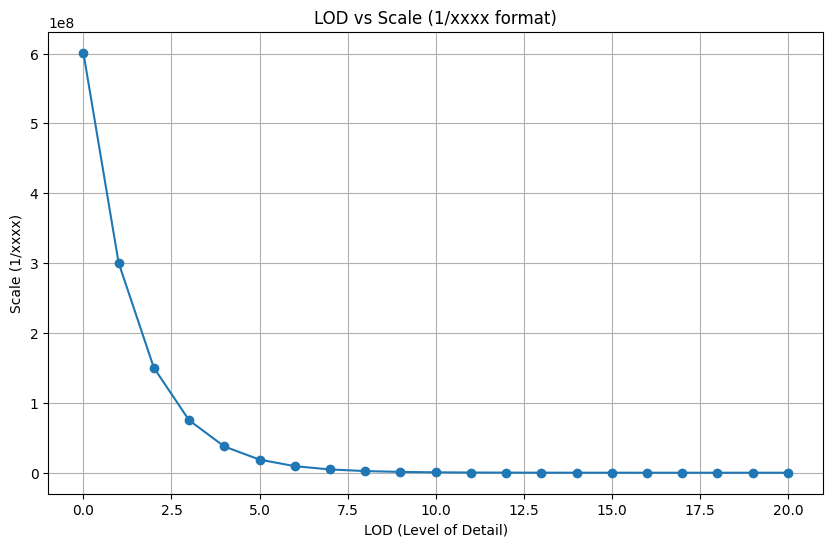

    Scale (1/xxxx)  Computed LOD
0      601125250.0 -1.601713e-16
1      300562625.0  1.000000e+00
2      150281313.0  2.000000e+00
3       75140656.0  3.000000e+00
4       37570328.0  4.000000e+00
5       18785164.0  5.000000e+00
6        9392582.0  6.000000e+00
7        4696291.0  7.000000e+00
8        2348146.0  8.000000e+00
9        1174073.0  9.000000e+00
10        587036.0  1.000000e+01
11        293518.0  1.100000e+01
12        146759.0  1.200000e+01
13         73380.0  1.300000e+01
14         36690.0  1.400000e+01
15         18345.0  1.500000e+01
16          9172.0  1.600000e+01
17          4586.0  1.700000e+01
18          2293.0  1.800000e+01
19          1147.0  1.900000e+01
20           573.0  2.000000e+01


In [10]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants for the computation
ellipsoid_semi_major_axis = 6378137  # WGS84 semi-major axis in meters (Earth's semi-major axis)
tile_size = 256  # Typical tile size in pixels (e.g., used in Google Maps)
lat = 0  # Latitude at equator (radians)
resolution = 1920  # Number of pixels on the display (width or height in pixels)
display_size = 0.5  # Length of the display in meters (e.g., 50 cm)

# LOD from 0 to 21
lod_values = np.arange(0, 21)

# Compute map size and scale for each LOD
map_sizes = tile_size * 2 ** lod_values
ground_resolutions = np.where(map_sizes != 0, (np.cos(lat) * 2 * np.pi * ellipsoid_semi_major_axis) / map_sizes, np.nan)
world_sizes = resolution * ground_resolutions  # This is the world size in meters based on resolution and ground resolution
scales = np.where(world_sizes != 0, display_size / world_sizes, np.nan)

# Convert scale to 1/xxxx format (mapping format) and round the results
scales_mapping_format = np.where(scales > 0, np.round(1 / scales).astype(int), np.nan)

# Create a DataFrame for LOD to Scale
lod_to_scale_df = pd.DataFrame({
    "LOD": lod_values,
    "Map Size (pixels)": map_sizes,
    "Ground Resolution (m/pixel)": ground_resolutions,
    "World Size (meters)": world_sizes,
    "Scale (1/xxxx)": scales_mapping_format
})

# Reverse: Scale to LOD
# We will compute the LOD from different scale values
scale_values = scales  # Reverse case, using computed scales
lod_computed = np.where(scale_values > 0, np.log2((scale_values * resolution * np.cos(lat) * 2 * np.pi * ellipsoid_semi_major_axis) / (display_size * tile_size)), np.nan)

# Create a DataFrame for Scale to LOD
scale_to_lod_df = pd.DataFrame({
    "Scale (1/xxxx)": scales_mapping_format,
    "Computed LOD": lod_computed
})

# Display the LOD to Scale DataFrame
print(lod_to_scale_df)

# Plotting the relationship between LOD and Scale (1/xxxx format)
plt.figure(figsize=(10, 6))
plt.plot(lod_values, scales_mapping_format, marker='o')
plt.title('LOD vs Scale (1/xxxx format)')
plt.xlabel('LOD (Level of Detail)')
plt.ylabel('Scale (1/xxxx)')
plt.grid(True)
plt.show()

# Display the Scale to LOD DataFrame
print(scale_to_lod_df)
